In [1]:
# Importa as bibliotecas usadas
import numpy as np
import pandas as pd

import matplotlib as mpl
from matplotlib import pyplot as plt
import bagpipes as pipes

Bagpipes: Latex turned off in rcParams, plots may look strange.


In [2]:
snap_to_z = pd.read_pickle('snap_to_z.pkl')
#etg_table = pd.read_pickle('mergers_ETGs.pkl')
etg_table = pd.read_pickle('catalogue_ETGs.pkl')

table_mass = np.array(etg_table['mass'])
table_sersic_mass = np.array(etg_table['sersic_mass'])
table_massformed = np.array(etg_table['massformed'])
table_SFR = np.array(etg_table['SFR'])
table_sSFR = np.array(etg_table['sSFR'])
table_met = np.array(etg_table['metallicity'])
table_dispvel = np.array(etg_table['dispvel'])

#U, B, V, K, g, r, i, z
table_photometrics = np.array([etg_table['U'], etg_table['g'], etg_table['r'], etg_table['i'], etg_table['z']]).T

trees = np.array(etg_table['tree'])

In [3]:
merger_data = pd.read_csv('catalogue_estimated.csv')
tmax = np.array(merger_data['tmax'])
fwhm = np.array(merger_data['fwhm'])
etg_massformed = np.array(merger_data['massformed'])

tree_mask = (tmax != np.nan) & (tmax > 0) & (fwhm > 0)

etg_photometrics = table_photometrics[tree_mask]
etg_met = table_met[tree_mask]
#etg_massformed = table_mass[tree_mask]
etg_sersic_mass = table_sersic_mass[tree_mask]
etg_SFR = table_SFR[tree_mask]
etg_dispvel = table_dispvel[tree_mask]
tmax = tmax[tree_mask]
fwhm = fwhm[tree_mask]

In [ ]:
def load_photo(ID):    
    row = int(ID)

    magnitudes_tng = etg_photometrics[row, :]
    fluxes = 10**((magnitudes_tng - 8.6)/-2.5) * 10**6
    fluxerrs = fluxes * 0.05  # 5% de erro numérico simulado

    photometry = np.column_stack((fluxes, fluxerrs))
    return photometry

sdss_filt_list = np.loadtxt("sdss-filters/sdss_filters.txt", dtype="str")

gal_id = 0
galaxy = pipes.galaxy(str(gal_id), load_photo, spectrum_exists=False, filt_list=sdss_filt_list)

lognormal = {}
lognormal["tmax"] = (0., 12.5)
# lognormal["tmax_prior"] = "Gaussian"
# lognormal["tmax_prior_mu"] = 5
# lognormal["tmax_prior_sigma"] = 2.5

lognormal["fwhm"] = (0.1, 10.)
# lognormal["fwhm_prior"] = "Gaussian"
# lognormal["fwhm_prior_mu"] = 1
# lognormal["fwhm_prior_sigma"] = 0.75

lognormal["massformed"] = (0.01, 15.)             # vary log_10(M*/M_solar) between 1 and 15
lognormal["massformed_prior"] = "Gaussian"
lognormal["massformed_prior_mu"] = 10.9
lognormal["massformed_prior_sigma"] = 0.2

lognormal["metallicity"] = (0., 2.5)            # vary Z between 0 and 2.5 Z_oldsolar
lognormal["metallicity_prior"] = "Gaussian"
lognormal["metallicity_prior_mu"] = 1.2
lognormal["metallicity_prior_sigma"] = 0.1

dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.

fit_instructions = {}
fit_instructions["redshift"] = 0
fit_instructions["lognormal"] = lognormal   
fit_instructions["dust"] = dust

fit_instructions["veldisp"] = (0., 400.)
# fit_instructions["veldisp_prior"] = "Gaussian"
# fit_instructions["veldisp_prior_mu"] = 150
# fit_instructions["veldisp_prior_sigma"] = 50

fit = pipes.fit(galaxy, fit_instructions)
fit.fit(verbose=False)

print("\nGalaxy Parameters:")
print(f"Massformed = {etg_massformed[gal_id]}")
print(f"Metallicity = {etg_met[gal_id]}")
print(f"Disp. Vel = {etg_dispvel[gal_id]}")
print(f"tmax = {tmax[gal_id]}")
print(f"fwhm = {fwhm[gal_id]}")


Bagpipes: fitting object 0

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    5
 *****************************************************

Completed in 15.7 seconds.
 ln(ev)=  -1005.2618382569019      +/-  0.11548809462311228     
 Total Likelihood Evaluations:         5225
 Sampling finished. Exiting MultiNest

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
lognormal:fwhm                 4.403      7.290      9.069
lognormal:massformed           3.195      8.556     12.555
lognormal:metallicity          0.407      1.128      1.915
lognormal:tmax                 0.011      0.042      0.081
veldisp                       82.473    201.341    330.999




/home/pedroand/Programs/miniconda3/envs/Bagpipes/lib/python3.14/site-packages/bagpipes/models/star_formation_history.py:268: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  tau, t0 = fsolve(lognorm_equations, (tau_guess, t0_guess),
/home/pedroand/Programs/miniconda3/envs/Bagpipes/lib/python3.14/site-packages/bagpipes/models/star_formation_history.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  self.component_sfrs[name] *= desired_mass/mass_norm
/home/pedroand/Programs/miniconda3/envs/Bagpipes/lib/python3.14/site-packages/bagpipes/models/star_formation_history.py:105: RuntimeWarning: invalid value encountered in multiply
  self.component_sfrs[name] *= desired_mass/mass_norm
/home/pedroand/Programs/miniconda3/envs/Bagpipes/lib/python3.14/site-packages/bagpipes/models/star_formation_history.py:28: RuntimeWarning: overflow encountered in exp
  tau = np.exp(T0_solve - tau_solve**2) - xmax
/home


Galaxy Parameters:
Massformed = 11.44449379151189
Metallicity = 0.1100482781422897
Disp. Vel = 306.9283142089844
tmax = 4.042554156885607
fwhm = 1.3875628292120832


OverflowError: cannot convert float infinity to integer

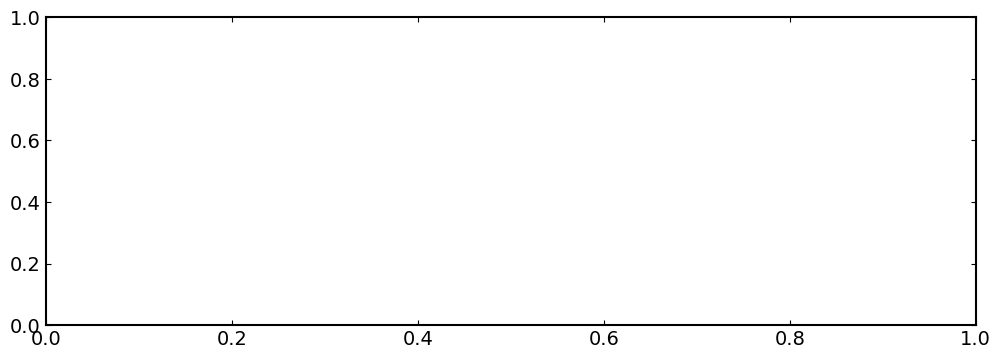

In [6]:
spec_wavs = np.linspace(2000, 12000, 2500)
spectra = []

lognormal = {}
lognormal["massformed"] = np.median(fit.posterior.samples["lognormal:massformed"])
lognormal["metallicity"] = np.median(fit.posterior.samples["lognormal:metallicity"])

lognormal["tmax"] = np.median(fit.posterior.samples["lognormal:tmax"])
lognormal["fwhm"] = np.median(fit.posterior.samples["lognormal:fwhm"])

# Adicionar variação na poeira dependendo da metalicidade?
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0

model_components = {}
model_components["lognormal"] = lognormal
model_components["dust"] = dust
model_components["redshift"] = 0.003
model_components["veldisp"] = np.median(fit.posterior.samples["veldisp"])

model = pipes.model_galaxy(model_components, spec_wavs=spec_wavs)
spectra.append(model.spectrum)

model.plot()
model.sfh.plot()

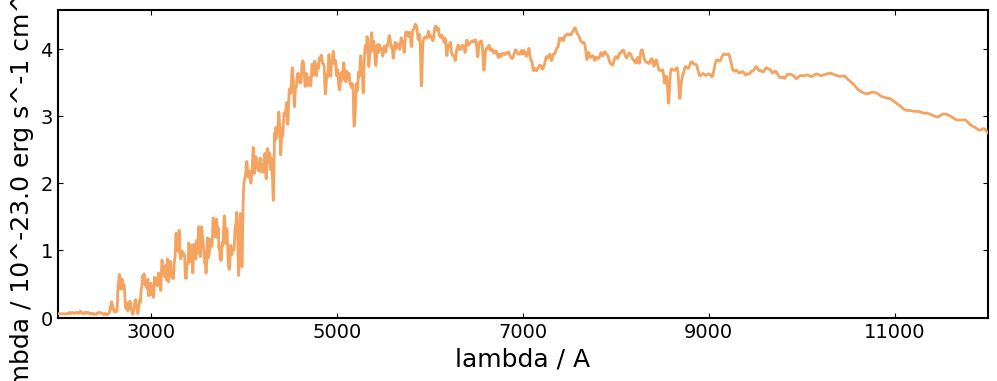

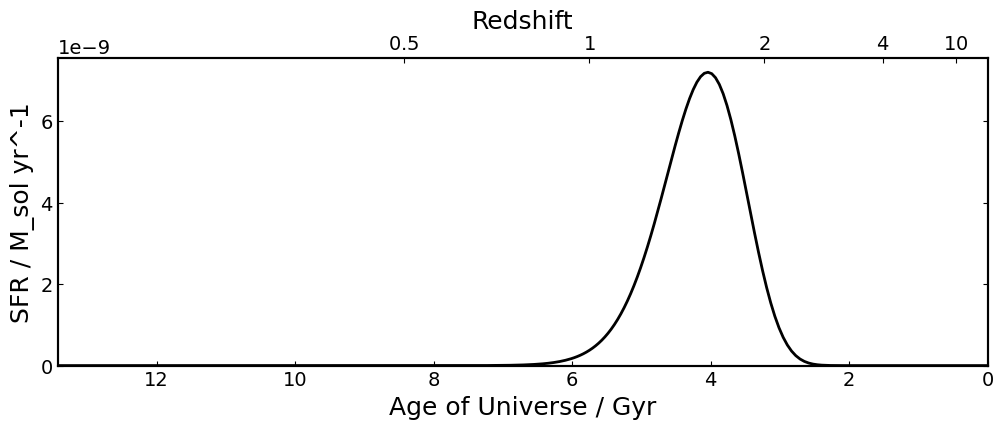

(<Figure size 1200x400 with 2 Axes>,
 <Axes: xlabel='Age of Universe / Gyr', ylabel='SFR / M_sol yr^-1'>)

In [ ]:
spec_wavs = np.linspace(2000, 12000, 2500)

lognormal = {}
lognormal["massformed"] = np.log10(etg_massformed[gal_id])
lognormal["metallicity"] = 10**etg_met[gal_id]

lognormal["tmax"] = tmax[gal_id]
lognormal["fwhm"] = fwhm[gal_id]

# Adicionar variação na poeira dependendo da metalicidade?
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0

model_components = {}
model_components["lognormal"] = lognormal
model_components["dust"] = dust
model_components["redshift"] = 0.003
model_components["veldisp"] = etg_dispvel[gal_id]

model = pipes.model_galaxy(model_components, spec_wavs=spec_wavs)
spectra.append(model.spectrum)

model.plot()
model.sfh.plot()

In [ ]:
from synphot import SourceSpectrum, SpectralElement, Observation
from synphot.models import Empirical1D
from astropy import units as u
from astropy.table import Table

filt_sdss_list = np.loadtxt("sdss-filters/sdss_filters.txt", dtype="str")
n_filters_sdss = len(filt_sdss_list)

mock_photo_sdss = np.full((2, n_filters_sdss), np.nan)

for i, spectrum in enumerate(spectra):
    wave_ang = spectrum[:, 0] # Angstroms
    flux_cgs = spectrum[:, 1] # erg/s/cm^2/A

    flux_units = u.erg / (u.s * u.cm**2 * u.AA)

    spec_synphot = SourceSpectrum(
        Empirical1D,
        points=wave_ang * u.AA,
        lookup_table=flux_cgs * flux_units
    )
        
    for j, filter_path in enumerate(filt_sdss_list):
        # MOCK SDSS
        filter_data = Table.read(filter_path, format="ascii")
        bp_wave = filter_data['col1'] * u.AA
        bp_trans = filter_data['col2']

        passband = SpectralElement(
            Empirical1D,
            points=bp_wave,
            lookup_table=bp_trans
        )

        obs_synphot = Observation(spec_synphot, passband, force="taper")
        ab_mag = obs_synphot.effstim(u.ABmag)

        mock_photo_sdss[i, j] = ab_mag.value

band_names_sdss = [p.split("/")[-1].replace(".dat", "") for p in filt_sdss_list]

# Dicionário com os nomes das bandas e seus índices no array
band_index_sdss = {name: j for j, name in enumerate(band_names_sdss)}

Text(0, 0.5, '$r - z$')

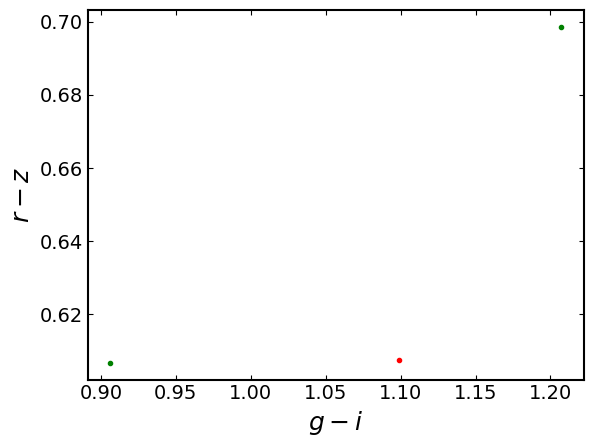

In [ ]:
plt.scatter(etg_table['g'][gal_id] - etg_table['i'][gal_id], etg_table['r'][gal_id] - etg_table['z'][gal_id], 
            c="red", marker=".", label="TNG100-1")

plt.scatter(mock_photo_sdss[:, band_index_sdss["SLOAN_SDSS.g"]] - mock_photo_sdss[:, band_index_sdss["SLOAN_SDSS.i"]], mock_photo_sdss[:, band_index_sdss["SLOAN_SDSS.r"]] - mock_photo_sdss[:, band_index_sdss["SLOAN_SDSS.z"]],
            c="green", marker=".", label="BAGPIPES-SDSS")

plt.xlabel(r"$g - i$")
plt.ylabel(r"$r - z$")